In [1]:
#other imports
import os
import numpy as np
os.chdir('C:/Code/Github/GLM-analysis/')

In [2]:
from DataHandlerDecoding import DataHandlerDecoding as datafun
from Plotter import Plotter as plotterfun
from DecoderAnalyzer import DecoderAnalyzer as analysisdec

In [3]:
#initialize class
# decoded_variables= {'sound_category', 'choice', 'photostim', 'outcome','shuffled/sound_category', 'shuffled/choice', 'shuffled/photostim', 'shuffled/outcome'}
decoded_variables= { 'photostim', 'shuffled/photostim'}

data_handler = datafun(decoded_variables=decoded_variables)  # Pass any initial data if needed

In [4]:
# LOAD INFO ABOUT DATASETS
info_dir = 'V:/Connie/results/opto_2024/context/mod'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)
# for dat in datasets:
#     print(dat)

# Indices to remove (example: remove datasets at indices 0 and 2)
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,15,16,18,19,20,21,22]
#remove_indices = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,6,8,9,10,11,12,13,15,16,18,19,20,21,22,23,24]
#remove_indices = [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #1
#remove_indices = [0,1,2,6,8,9,10,11,16,19,22,24] #7 no outcome
remove_indices = [0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]
for dat in datasets:
    print(dat)

('HA2-1L', '2023-05-05', 'V:')


In [5]:
#LOAD ACTUAL DATASETS 
save_results = os.path.join(f'V:/Connie/results/glm_decoding/prelim')
os.makedirs(save_results, exist_ok=True)
cat_results = []

model_type = 'GLM_3nmf_pre'
#results_pre,results_pre_all = data_handler.process_multiple_datasets(datasets, model_type)
# results_pre,results_pre_all_sb, cat_results = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives means across sc or pop
# results_pre_all['HA11-1R_2023-04-13']['sound_category'].keys() - gives each split!

model_type = 'GLM_3nmf_passive'
#results_pass,results_pass_all = data_handler.process_multiple_datasets(datasets, model_type)
results_pass,results_pass_all_sb, cat_results = data_handler.process_multiple_datasets(datasets, model_type,single_balanced=True) 

Processing dataset: HA2-1L_2023-05-05
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/1_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/2_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/3_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/4_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/5_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/decoding/6_1/
decoder_results_shuffled_photostim.mat
decoder_results_regular_photostim.mat
V:/Connie/ProcessedData/HA2-1L/2023-05-05/GLM_3nmf_passive/dec

In [6]:
#Initialize plotting class

# Define colors dictionary
colors_dict = {
    'pyr': (0.37, 0.75, 0.49), 
    'som': (0.17, 0.35, 0.8), 
    'pv': (0.82, 0.04, 0.04)
}

plotter = plotterfun(data = None,celltypecolors=colors_dict, save_results= save_results)

In [7]:
# for dataset in results_pre_all_sb:
#     print(dataset)
#     print(np.shape(results_pre_all_sb[dataset]['photostim']['sc_cumulative_information_mean']))

# del results_pre_all_sb['HE1-00_2023-05-30']

#np.shape(results_pass_all_sb['HE1-00_2023-05-30']['shuffled/sound_category']['sc_cumulative_information_mean'])
# for dataset in results_pre_all_sb:
#     print(np.shape(cat_results[dataset]['shuffled/sound_category'][2]['sc_cumulative_information']))
# del cat_results['HE4-1L1R_2023-08-21']

In [8]:
# get shuffled data into frames x neurons x total shuffles across splits (50 * 10 = 500)
shuffled_structure = data_handler.create_shuffled_distribution_structure(decoder_type = 'photostim', metric = 'sc_instantaneous_information')

HA2-1L_2023-05-05


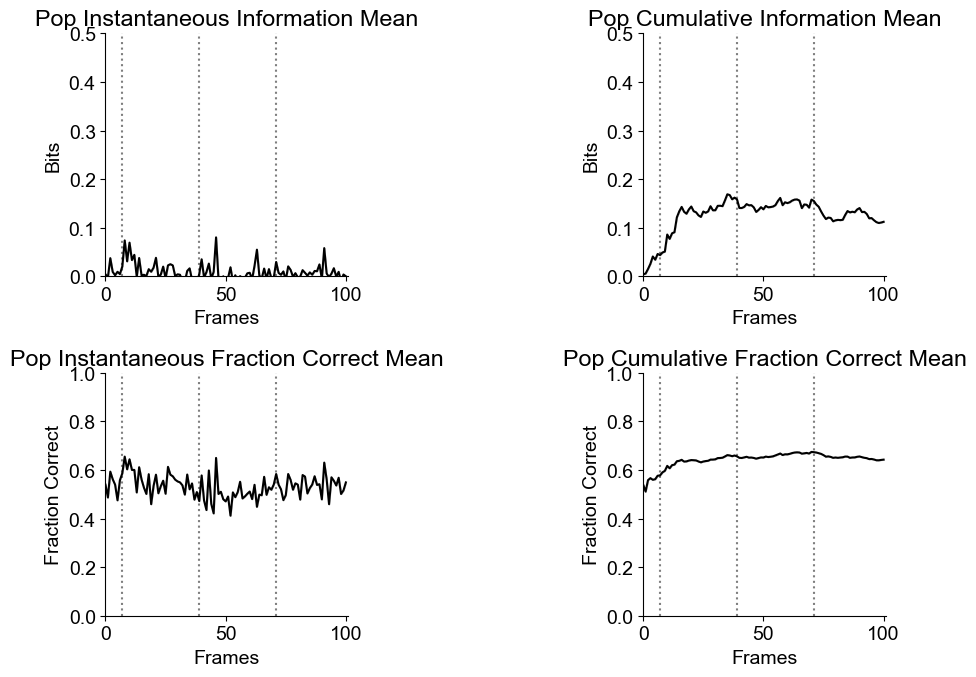

In [9]:
# Plot population decoders across datasets
results_pre_all = results_pass_all_sb 
current_decoder_type = 'photostim'   
# Usage example:
plotter.plot_decoding_results(results_pre_all, 
                     decoder_type= current_decoder_type,
                     plot_type='pop',
                     save_dir=plotter.save_results,
                     #xlim = (0,100),
                     ylim = [0.5, 0.5, 1, 1]) 

In [10]:
# Create an instance of AnalysisManager, passing in the plotter module
analysis_dec = analysisdec()

In [11]:
#DECIDE WHETHER OR NOT TO USE END FRAME
peaks_by_celltype = analysis_dec.analyze_peaks_by_celltype( results_pre_all,shuffled_structure, decoder_type=current_decoder_type, start_frame=14, end_frame = 100,significance_percentile = 95) #, end_frame = 100

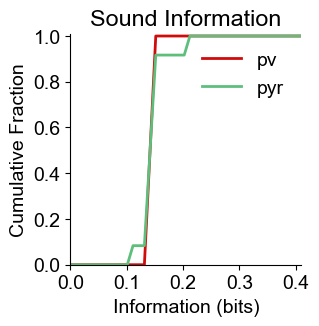

c:\Code\Github\GLM-analysis\Plotter.py:1165: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


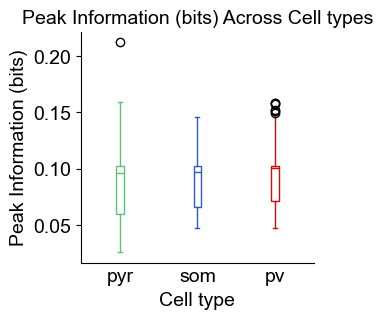

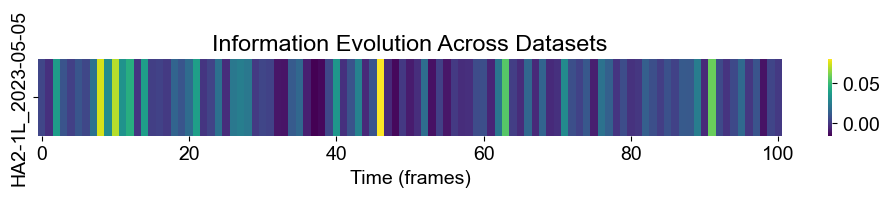

In [12]:
#PLOT DISTRIBUTIONS OF SIGINIFICANT NEURONS!
metric_to_plot = 'sc_instantaneous_information_mean'
cdf_data, cell_labels = analysis_dec.format_peaks_for_cdf(peaks_by_celltype,metric = metric_to_plot, significant_only=True)
all_peaks, neuron_groups = analysis_dec.format_peaks_for_boxplot(peaks_by_celltype, metric = metric_to_plot, significant_only=False)

#cdf
plotter.plot_cdf_coupling_index(np.array(cdf_data['all']['peaks']),
                                cell_labels,
                                colors = plotter.celltypecolors,
                                title='Sound Information',
                                xlabel = 'Information (bits)',
                                xval=.4,
                                xint=0.1)

#make boxplot!
plotter.box_plot(
    data=all_peaks,
    neuron_groups=neuron_groups,
    colors=plotter.celltypecolors,
    measure_string='Peak Information (bits)'
)

#heatmap across datasets
plotter.plot_decoding_heatmap_datasets(results_pre_all, decoder_type= current_decoder_type, metric = 'pop_instantaneous_information_mean')

In [13]:
def plot_single_neuron_analysis(results_dict, decoder_type='sound_category', start_frame= 14, end_frame = None):
    print(start_frame)
    """Comprehensive single neuron decoding visualization"""
    
    # 1. Neuron Performance Heatmap
    plt.figure(figsize=(12, 8))
    for dataset in results_dict:
        data = results_dict[dataset][decoder_type]['sc_cumulative_information_mean']
        celltype_array = results_dict[dataset]['celltype_array']
        
        # Sort neurons by cell type and performance
        max_info = np.max(data[start_frame:, :], axis=0)
        sort_idx = np.argsort(max_info)
        
        plt.subplot(len(results_dict), 1, list(results_dict.keys()).index(dataset) + 1)
        sns.heatmap(data[:, sort_idx].T, 
                   cmap='viridis',
                   xticklabels=20,
                   yticklabels=False)
        plt.title(f'{dataset} Single Neuron Decoding')
    plt.tight_layout()
    
    # 2. Best Neurons Analysis
    # Dictionary to store neuron IDs for each dataset and cell type
    neuron_ids_by_dataset = {}
    fig, axes = plt.subplots(1, 2, figsize=(6, 3))  # 1 row, 2 columns
    for cel_index,(celltype, color) in enumerate(plotter.celltypecolors.items()):
        all_peaks = []
        all_peaks_locs = []
        for dataset in results_dict:
            # Initialize a dictionary for this dataset if not already present
            if dataset not in neuron_ids_by_dataset:
                neuron_ids_by_dataset[dataset] = {}

            # Initialize a list for this cell type in the current dataset
            if celltype not in neuron_ids_by_dataset[dataset]:
                neuron_ids_by_dataset[dataset][celltype] = []
            
            peaks_by_celltype = analyze_peaks_by_celltype( results_dict, decoder_type=decoder_type, start_frame=start_frame, end_frame = end_frame)
            peaks = peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_values']
            peaks_locs = peaks_by_celltype[dataset][celltype]['sc']['sc_instantaneous_information_mean']['peak_frames']    
            if len(peaks) > 0:
                max_peaks = sorted(peaks)  # Sorted in ascending order
                top_5 = max_peaks[-5:]     # Slice the last 5 elements (highest values)
                all_peaks.extend(top_5)

                # Get the corresponding peak locations  
                top_5_locs = [peaks_locs[max_peaks.index(p)] for p in top_5]
                # Use the indices from the sorting step to ensure uniqueness
                sorted_indices = np.argsort(peaks)
                top_5_indices = sorted_indices[-5:]  # Indices of the top 5 values
                neuron_ids_by_dataset[dataset][celltype].extend(top_5_indices.tolist())


                # Add neuron IDs (indices) to the dictionary
                #neuron_ids_by_dataset[dataset][celltype].extend(top_5_ids)

                all_peaks_locs.extend(top_5_locs)
        # Plotting histograms on subplots
        axes[0].hist(all_peaks, alpha=1.0, color=color, label=celltype, histtype='step', linewidth=2)
        axes[0].set_xlabel('Information (bits)')  # Correct method to set the x-axis label
        axes[0].spines['top'].set_visible(False)
        axes[0].spines['right'].set_visible(False)
        axes[0].set_box_aspect(1)

        axes[1].hist(all_peaks_locs, alpha=1.0, color=color, label=celltype, histtype='step', linewidth=2)
        axes[1].set_xlabel('Peak Frame')  # Correct method to set the x-axis label
        axes[1].spines['top'].set_visible(False)
        axes[1].spines['right'].set_visible(False)
        axes[1].set_box_aspect(1)

    # Add legend and title
    #fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)  # Adjust legend location
    fig.suptitle('Top 5 Neurons Distribution by Cell Type')

    # Adjust layout to avoid overlap
    plt.tight_layout() #(rect=[0, 0.03, .8, 0.95]) #(rect=[0, 0.03, 1, 0.95])  # Leave space for the title and legend

    # Show the plot
    plt.show()
    
    # 3. Time Course by Cell Type
    plt.figure(figsize=(3, 3))
    for cel_index,(celltype, color) in enumerate(plotter.celltypecolors.items()):
        all_traces = []
        for dataset in results_dict:
            if end_frame is None:
                end_frame = len(data)

            traces = results_dict[dataset][decoder_type]['sc_instantaneous_information_mean'][0:end_frame,:]

            celltype_idx = results_dict[dataset]['celltype_array'] == cel_index
            if np.any(celltype_idx):
                mean_trace = np.mean(traces[:, celltype_idx], axis=1)
                all_traces.append(mean_trace)
        
        mean = np.mean(all_traces, axis=0)
        sem = np.std(all_traces, axis=0) / np.sqrt(len(all_traces))
        plt.plot(mean, color=color, label=celltype)
        # Get the current Axes object
        ax = plt.gca()   
        ax.axvline(x = start_frame, color='k', linestyle=':', alpha=0.5)
        plt.fill_between(range(len(mean)), mean-sem, mean+sem, alpha=0.2, color=color)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        ax.set_box_aspect(1)
    
    plt.legend()
    plt.title('Average Information Time Course by Cell Type')
    plt.xlabel('Time (frames)')
    plt.ylabel('Information (bits)')
    
    plt.show()

    return neuron_ids_by_dataset


In [14]:
neuron_ids_by_dataset = plot_single_neuron_analysis(results_pre_all, decoder_type= 'sound_category' , start_frame = 14,end_frame = 100)

14


NameError: name 'plt' is not defined

In [ ]:
neuron_ids_by_dataset

{'HA11-1R_2023-04-13': {'pyr': [105, 2, 9, 338, 182],
  'som': [5, 7, 0, 4, 6],
  'pv': [1, 29, 12, 6, 13]},
 'HA2-1L_2023-05-05': {'pyr': [119, 80, 199, 156, 26],
  'som': [2, 5, 10, 13, 6],
  'pv': [10, 0, 7, 8, 1]},
 'HA1-00_2023-06-29': {'pyr': [46, 78, 25, 15, 130],
  'som': [2, 1, 5, 15, 6],
  'pv': [7, 3, 8, 9, 4]},
 'HA1-00_2023-08-28': {'pyr': [140, 80, 73, 30, 85],
  'som': [6, 1, 11, 7, 9],
  'pv': [7, 19, 3, 15, 13]},
 'HE4-1L1R_2023-08-21': {'pyr': [238, 93, 257, 42, 230],
  'som': [10, 3, 16, 5, 9],
  'pv': [13, 24, 35, 15, 6]},
 'HE4-1L1R_2023-08-24': {'pyr': [47, 103, 182, 49, 189],
  'som': [3, 2, 5, 6, 4],
  'pv': [14, 25, 1, 6, 3]},
 'HA11-1R_2023-05-01': {'pyr': [159, 267, 35, 188, 128],
  'som': [10, 16, 18, 1, 19],
  'pv': [32, 28, 11, 18, 23]},
 'HA11-1R_2023-05-02': {'pyr': [80, 205, 18, 299, 153],
  'som': [0, 6, 7, 1, 4],
  'pv': [4, 2, 0, 11, 5]},
 'HA2-1L_2023-04-28': {'pyr': [232, 71, 23, 140, 133],
  'som': [6, 1, 9, 13, 4],
  'pv': [0, 2, 8, 25, 29]},
 'H